In [1]:
!pip install datasets -q

In [11]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)

!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [12]:
!kaggle datasets download -d shashwatwork/consume-complaints-dataset-fo-nlp

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/consume-complaints-dataset-fo-nlp
License(s): copyright-authors
100% 19.8M/19.8M [00:01<00:00, 18.4MB/s]



In [13]:
import zipfile
import os

zip_file = "consume-complaints-dataset-fo-nlp.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("consumer_complaints")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [14]:
os.listdir("consumer_complaints")

['complaints_processed.csv']

In [15]:
import glob

csv_files = glob.glob(
    "consumer_complaints/**/*.csv",
    recursive=True
)

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
consumer_complaints/complaints_processed.csv


In [18]:
import pandas as pd

file_path = csv_files[0]

df = pd.read_csv(
    file_path,
    low_memory=False
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (162421, 3)


,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [19]:
print(df.columns.tolist())

['Unnamed: 0', 'product', 'narrative']


In [20]:
for col in df.columns:
    print(col)

Unnamed: 0
product
narrative


In [22]:
data = df[['product', 'narrative']].copy()

data.columns = ['category', 'complaint']

display(data.head())

,category,complaint
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...


In [23]:
print("Missing values:")
print(data.isnull().sum())

Missing values:
category      0
complaint    10
dtype: int64


In [24]:
data = data.dropna(subset=['complaint', 'category'])

print("Dataset shape:", data.shape)

Dataset shape: (162411, 2)


In [25]:
data = data.drop_duplicates(subset=['complaint'])

print("Shape after removing duplicates:", data.shape)

Shape after removing duplicates: (124472, 2)


In [26]:
print(data['category'].value_counts())

category
credit_reporting       56240
debt_collection        21057
mortgages_and_loans    18723
credit_card            14983
retail_banking         13469
Name: count, dtype: int64


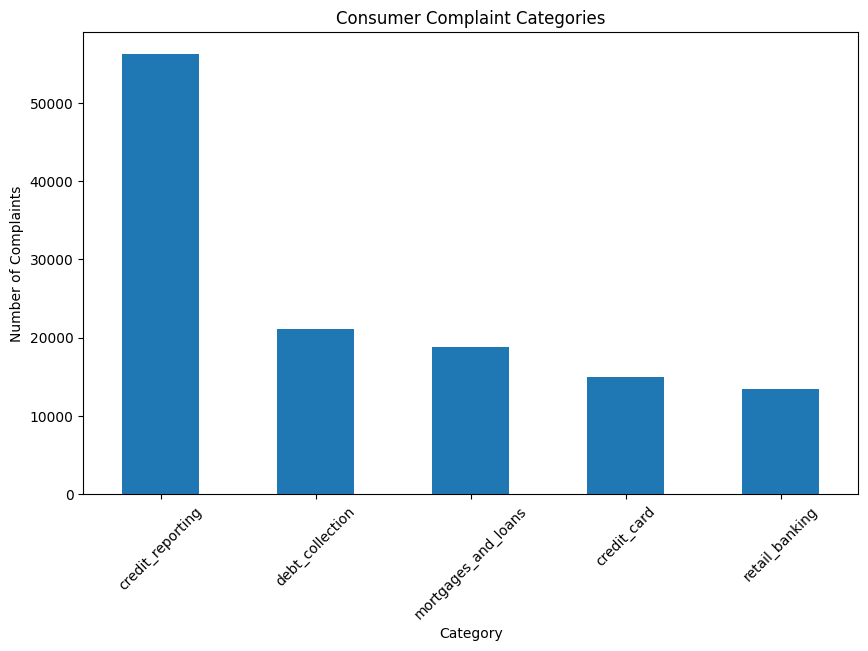

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

data['category'].value_counts().plot(kind='bar')

plt.title("Consumer Complaint Categories")
plt.xlabel("Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)

plt.show()

In [28]:
import re

def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [29]:
data['clean_complaint'] = data['complaint'].apply(clean_text)

display(
    data[['complaint', 'clean_complaint']].head()
)

,complaint,clean_complaint
0,purchase order day shipping amount receive pro...,purchase order day shipping amount receive pro...
1,forwarded message date tue subject please inve...,forwarded message date tue subject please inve...
2,forwarded message cc sent friday pdt subject f...,forwarded message cc sent friday pdt subject f...
3,payment history missing credit report speciali...,payment history missing credit report speciali...
4,payment history missing credit report made mis...,payment history missing credit report made mis...


In [30]:
X = data['clean_complaint']
y = data['category']

print("Input X:", X.shape)
print("Target y:", y.shape)

Input X: (124472,)
Target y: (124472,)


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 99577
Testing data: 24895


In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (99577, 20000)
TF-IDF Testing Shape: (24895, 20000)


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Training Shape:", X_train_tfidf.shape)
print("TF-IDF Testing Shape:", X_test_tfidf.shape)

TF-IDF Training Shape: (99577, 20000)
TF-IDF Testing Shape: (24895, 20000)


In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:",
      lr_accuracy * 100, "%")

Logistic Regression Accuracy: 85.75617593894357 %


In [38]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("Linear SVM Accuracy:",
      svm_accuracy * 100, "%")

Linear SVM Accuracy: 85.34243824061056 %


In [43]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_pred)

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, lr_pred)

# Linear SVM
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Naive Bayes Accuracy:", nb_accuracy * 100, "%")
print("Logistic Regression Accuracy:", lr_accuracy * 100, "%")
print("Linear SVM Accuracy:", svm_accuracy * 100, "%")

Naive Bayes Accuracy: 82.74352279574212 %
Logistic Regression Accuracy: 85.75617593894357 %
Linear SVM Accuracy: 85.34243824061056 %


In [45]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy (%)": [
        nb_accuracy * 100,
        lr_accuracy * 100,
        svm_accuracy * 100
    ]
})

display(results)

,Model,Accuracy (%)
0,Naive Bayes,82.743523
1,Logistic Regression,85.756176
2,Linear SVM,85.342438


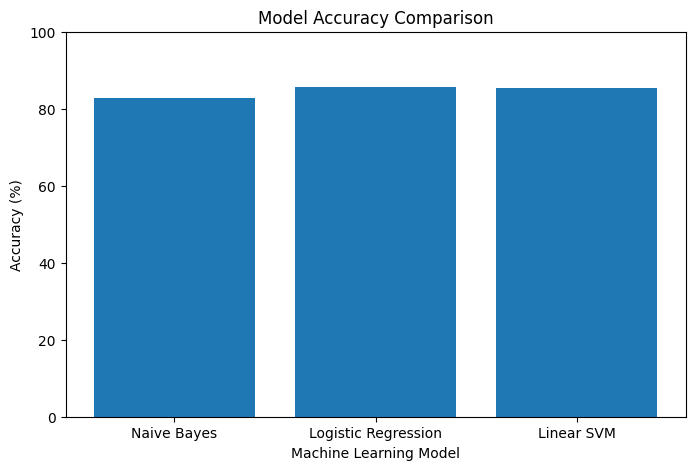

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy (%)"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.show()

In [47]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        svm_pred
    )
)

                     precision    recall  f1-score   support

        credit_card       0.80      0.78      0.79      2997
   credit_reporting       0.88      0.90      0.89     11248
    debt_collection       0.80      0.75      0.78      4211
mortgages_and_loans       0.86      0.85      0.85      3745
     retail_banking       0.86      0.88      0.87      2694

           accuracy                           0.85     24895
          macro avg       0.84      0.83      0.84     24895
       weighted avg       0.85      0.85      0.85     24895



In [48]:
def predict_complaint(text):

    cleaned_text = clean_text(text)

    text_vector = tfidf.transform([cleaned_text])

    prediction = svm_model.predict(text_vector)

    return prediction[0]

In [49]:
complaint = "I am having problems with my credit card payment"

result = predict_complaint(complaint)

print("Customer Complaint:")
print(complaint)

print("\nPredicted Category:")
print(result)

Customer Complaint:
I am having problems with my credit card payment

Predicted Category:
credit_card


In [ ]:
while True:

    user_input = input(
        "\nEnter customer complaint "
        "(type 'exit' to stop): "
    )

    if user_input.lower() == 'exit':
        print("Program ended.")
        break

    prediction = predict_complaint(user_input)

    print("\nPredicted Category:")
    print("👉", prediction)


Enter customer complaint (type 'exit' to stop): I have a problem with my credit card

Predicted Category:
👉 credit_card

Enter customer complaint (type 'exit' to stop): I am having an issue with my bank account

Predicted Category:
👉 retail_banking

Enter customer complaint (type 'exit' to stop): stop

Predicted Category:
👉 debt_collection

Enter customer complaint (type 'exit' to stop): I am having an issue with my bank account

Predicted Category:
👉 retail_banking
